# 02 – Modeling & Evaluation (Baseline)
**Projekt:** StepSense | ML4B SoSe 2026 | Gruppe: NoNames
**CRISP-DM Phasen:** Modeling + Evaluation

## Inhalt
1. Imports & Konfiguration
2. Daten laden
3. Baseline-Modell (Decision Tree)
4. Modellvergleich mit Cross-Validation
5. Bestes Modell – finale Evaluation
6. Konfusionsmatrix & Per-Klasse Metriken
7. Feature Importance
8. Modell exportieren
9. Mixed-Evaluation
10. Zusammenfassung & Bias-Diskussion


## 1. Imports & Konfiguration

In [117]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)

warnings.filterwarnings("ignore")

PROCESSED_PATH = "../data/processed"
MIXED_PATH     = "../data/mixed"
RANDOM_STATE   = 42

# Muss mit Notebook 01 uebereinstimmen
SENSOR_PREFIX = {
    "Accelerometer": "acc",
    "Gyroscope":     "gyro",
    "Orientation":   "orie",
}
SENSOR_COLUMNS = {
    "Accelerometer": ["x", "y", "z"],
    "Gyroscope":     ["x", "y", "z"],
    "Orientation":   ["roll", "pitch", "yaw"],
}

print("Setup abgeschlossen.")

Setup abgeschlossen.


## 2. Daten laden

In [118]:
# Feature-Namen laden
with open(f"{PROCESSED_PATH}/feature_names.txt") as f:
    feature_cols = [line.strip() for line in f.readlines()]

# Scaler laden
with open(f"{PROCESSED_PATH}/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# Train / Val / Test laden
X_train = pd.read_csv(f"{PROCESSED_PATH}/X_train.csv")
X_val   = pd.read_csv(f"{PROCESSED_PATH}/X_val.csv")
X_test  = pd.read_csv(f"{PROCESSED_PATH}/X_test.csv")
y_train = pd.read_csv(f"{PROCESSED_PATH}/y_train.csv").squeeze()
y_val   = pd.read_csv(f"{PROCESSED_PATH}/y_val.csv").squeeze()
y_test  = pd.read_csv(f"{PROCESSED_PATH}/y_test.csv").squeeze()

# Train + Val zusammenfuehren fuer Cross-Validation
X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train:      {X_train.shape[0]:>5} Fenster x {X_train.shape[1]} Features")
print(f"Validation: {X_val.shape[0]:>5} Fenster")
print(f"Test:       {X_test.shape[0]:>5} Fenster")
print(f"Train+Val:  {X_trainval.shape[0]:>5} Fenster (fuer Cross-Validation)")
print(f"\nKlassenverteilung Train:")
print(y_train.value_counts().sort_index().to_string())


Train:       1313 Fenster x 72 Features
Validation:   281 Fenster
Test:         282 Fenster
Train+Val:   1594 Fenster (fuer Cross-Validation)

Klassenverteilung Train:
label
Gehen            408
Laufen           279
Liegen           291
Stehen           204
Treppe_hoch       57
Treppe_runter     74


## 3. Baseline-Modell – Decision Tree

Ein einfacher Decision Tree als Ausgangspunkt (Baseline).  
Kein Hyperparameter-Tuning — Standardeinstellungen mit `class_weight='balanced'` wegen Klassenungleichgewicht.


In [119]:
baseline = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_val)
acc_baseline = accuracy_score(y_val, y_pred_baseline)
f1_baseline  = f1_score(y_val, y_pred_baseline, average="weighted")

print(f"=== Baseline: Decision Tree ===")
print(f"Accuracy (Val):          {acc_baseline:.4f}")
print(f"F1 gewichtet (Val):      {f1_baseline:.4f}")
print()
print(classification_report(y_val, y_pred_baseline, zero_division=0))


=== Baseline: Decision Tree ===
Accuracy (Val):          0.9715
F1 gewichtet (Val):      0.9716

               precision    recall  f1-score   support

        Gehen       0.99      0.98      0.98        87
       Laufen       0.98      1.00      0.99        60
       Liegen       0.98      0.97      0.98        62
       Stehen       0.96      0.98      0.97        44
  Treppe_hoch       0.80      1.00      0.89        12
Treppe_runter       1.00      0.81      0.90        16

     accuracy                           0.97       281
    macro avg       0.95      0.96      0.95       281
 weighted avg       0.97      0.97      0.97       281



## 4. Modellvergleich – Cross-Validation

5-fache Stratified Cross-Validation auf Train+Val.  
Metriken: gewichtetes F1 (Hauptmetrik wegen Klassenungleichgewicht) und Accuracy.


In [120]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Decision Tree":       DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM":                 SVC(class_weight="balanced", kernel="rbf", random_state=RANDOM_STATE),
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X_trainval, y_trainval,
        cv=cv,
        scoring={"f1_weighted": "f1_weighted", "accuracy": "accuracy"},
        n_jobs=-1
    )
    cv_results[name] = {
        "F1 gewichtet (mean)": scores["test_f1_weighted"].mean(),
        "F1 gewichtet (std)":  scores["test_f1_weighted"].std(),
        "Accuracy (mean)":     scores["test_accuracy"].mean(),
        "Accuracy (std)":      scores["test_accuracy"].std(),
    }
    print(f"{name:<22} F1={scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}  |  Acc={scores['test_accuracy'].mean():.4f}")

df_cv = pd.DataFrame(cv_results).T.round(4)
print()
print(df_cv.to_string())


Decision Tree          F1=0.9671 ± 0.0113  |  Acc=0.9674
Random Forest          F1=0.9855 ± 0.0052  |  Acc=0.9856
Gradient Boosting      F1=0.9823 ± 0.0066  |  Acc=0.9824
KNN                    F1=0.9799 ± 0.0055  |  Acc=0.9799
SVM                    F1=0.9818 ± 0.0072  |  Acc=0.9818

                   F1 gewichtet (mean)  F1 gewichtet (std)  Accuracy (mean)  Accuracy (std)
Decision Tree                   0.9671              0.0113           0.9674          0.0110
Random Forest                   0.9855              0.0052           0.9856          0.0051
Gradient Boosting               0.9823              0.0066           0.9824          0.0065
KNN                             0.9799              0.0055           0.9799          0.0055
SVM                             0.9818              0.0072           0.9818          0.0073


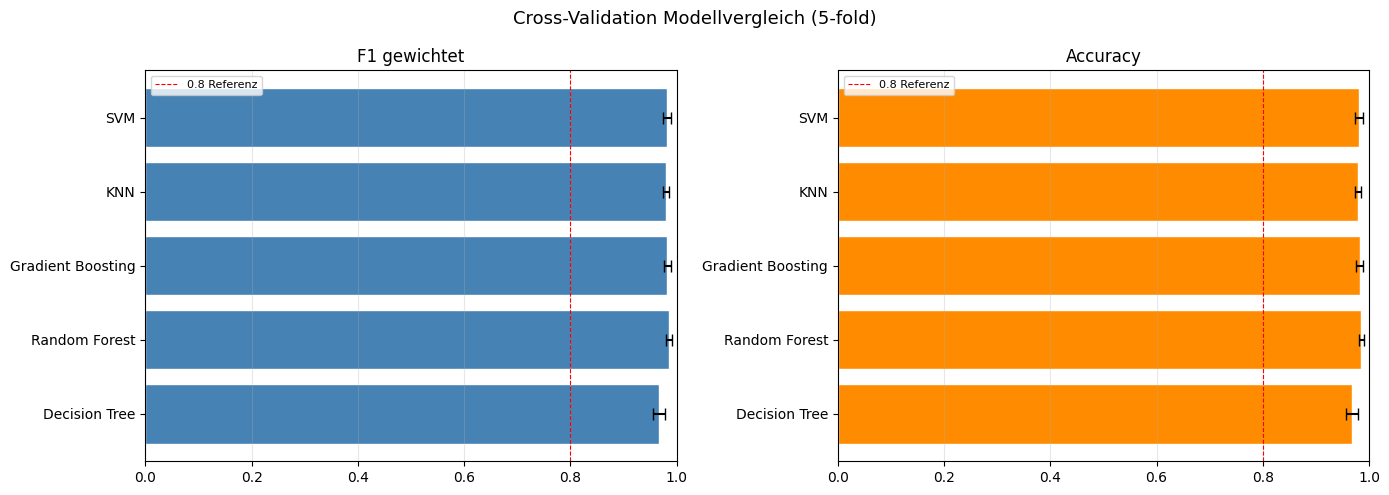

In [121]:
# Modellvergleich visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cross-Validation Modellvergleich (5-fold)", fontsize=13)

names = list(cv_results.keys())
f1_means  = [cv_results[n]["F1 gewichtet (mean)"] for n in names]
f1_stds   = [cv_results[n]["F1 gewichtet (std)"]  for n in names]
acc_means = [cv_results[n]["Accuracy (mean)"]      for n in names]
acc_stds  = [cv_results[n]["Accuracy (std)"]       for n in names]

axes[0].barh(names, f1_means, xerr=f1_stds, color="steelblue", edgecolor="white", capsize=4)
axes[0].set_title("F1 gewichtet")
axes[0].set_xlim(0, 1)
axes[0].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", alpha=0.3)

axes[1].barh(names, acc_means, xerr=acc_stds, color="darkorange", edgecolor="white", capsize=4)
axes[1].set_title("Accuracy")
axes[1].set_xlim(0, 1)
axes[1].axvline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/model_comparison_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Bestes Modell – Training & finale Evaluation

Das Modell mit dem hoechsten CV F1-Score wird auf dem vollstaendigen Train+Val Datensatz trainiert  
und abschliessend auf dem **Test-Set** evaluiert (einmalig, kein weiteres Tuning).


In [122]:
# Bestes Modell automatisch auswaehlen
best_name = max(cv_results, key=lambda n: cv_results[n]["F1 gewichtet (mean)"])
print(f"Bestes Modell (CV F1): {best_name}")
print(f"  F1 = {cv_results[best_name]['F1 gewichtet (mean)']:.4f} ± {cv_results[best_name]['F1 gewichtet (std)']:.4f}")

# Auf Train+Val neu trainieren
best_model = models[best_name]
best_model.fit(X_trainval, y_trainval)

# Finale Evaluation auf Test-Set
y_pred_test = best_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average="weighted")

print(f"\n=== Finale Test-Set Evaluation: {best_name} ===")
print(f"Accuracy:        {acc_test:.4f}")
print(f"F1 gewichtet:    {f1_test:.4f}")


Bestes Modell (CV F1): Random Forest
  F1 = 0.9855 ± 0.0052

=== Finale Test-Set Evaluation: Random Forest ===
Accuracy:        0.9929
F1 gewichtet:    0.9929


## 6. Konfusionsmatrix & Per-Klasse Metriken

Fokus auf Treppe_hoch und Treppe_runter (Minderheitsklassen).


In [123]:
# Classification Report
present_classes = sorted(y_test.unique())
print(classification_report(y_test, y_pred_test, labels=present_classes, zero_division=0))


               precision    recall  f1-score   support

        Gehen       0.98      1.00      0.99        88
       Laufen       1.00      0.97      0.98        60
       Liegen       1.00      1.00      1.00        63
       Stehen       1.00      1.00      1.00        44
  Treppe_hoch       1.00      1.00      1.00        12
Treppe_runter       1.00      1.00      1.00        15

     accuracy                           0.99       282
    macro avg       1.00      0.99      1.00       282
 weighted avg       0.99      0.99      0.99       282



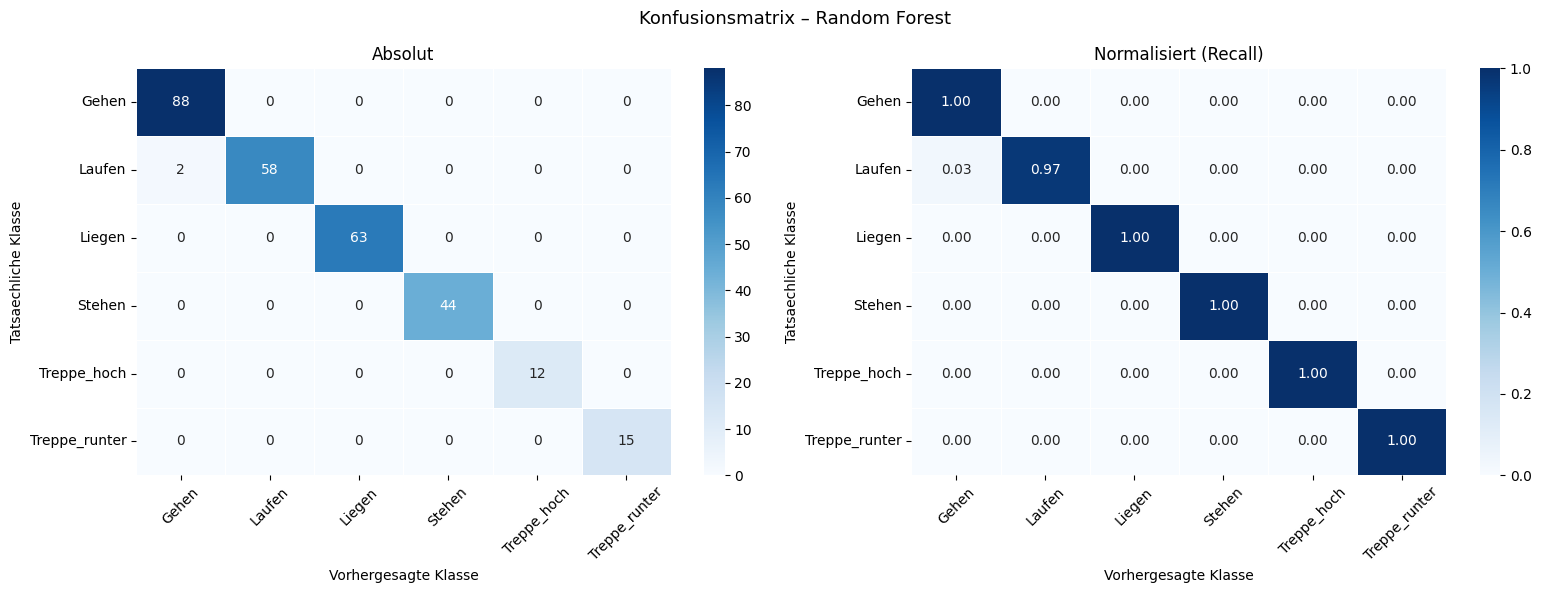

In [124]:
# Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred_test, labels=present_classes)
cm_norm = confusion_matrix(y_test, y_pred_test, labels=present_classes, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Konfusionsmatrix – {best_name}", fontsize=13)

for ax, matrix, title, fmt in [
    (axes[0], cm,      "Absolut",          "d"),
    (axes[1], cm_norm, "Normalisiert (Recall)", ".2f"),
]:
    sns.heatmap(
        matrix, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=present_classes, yticklabels=present_classes,
        ax=ax, linewidths=0.5
    )
    ax.set_title(title)
    ax.set_ylabel("Tatsaechliche Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()


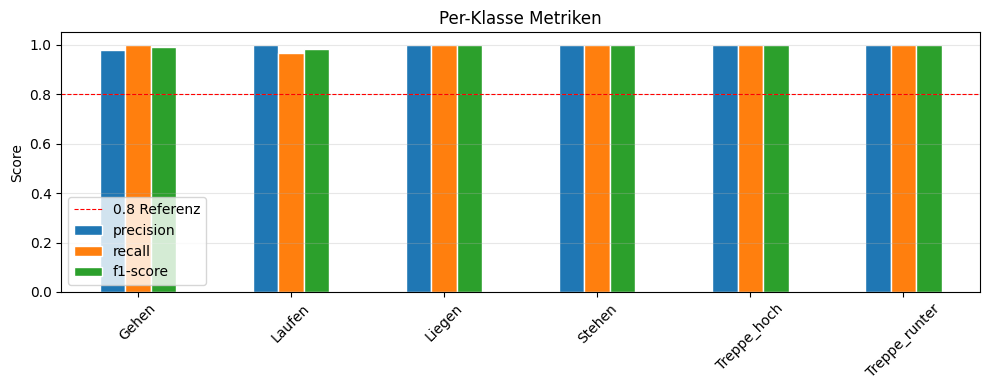

               precision  recall  f1-score  support
Gehen              0.978   1.000     0.989     88.0
Laufen             1.000   0.967     0.983     60.0
Liegen             1.000   1.000     1.000     63.0
Stehen             1.000   1.000     1.000     44.0
Treppe_hoch        1.000   1.000     1.000     12.0
Treppe_runter      1.000   1.000     1.000     15.0


In [125]:
# Per-Klasse F1 / Precision / Recall
report = classification_report(y_test, y_pred_test, labels=present_classes,
                                output_dict=True, zero_division=0)
df_report = pd.DataFrame(report).T.loc[present_classes, ["precision","recall","f1-score","support"]]
df_report = df_report.round(3)

fig, ax = plt.subplots(figsize=(10, 4))
df_report[["precision","recall","f1-score"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Per-Klasse Metriken")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.axhline(0.8, color="red", linestyle="--", linewidth=0.8, label="0.8 Referenz")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PROCESSED_PATH}/per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_report.to_string())


## 7. Feature Importance

Top 20 Features:
          Feature  Importance
orie_pitch_energy    0.061863
 orie_pitch_range    0.057955
       gyro_x_min    0.050205
   orie_pitch_std    0.047297
   orie_pitch_min    0.041737
     acc_z_energy    0.038925
        acc_z_iqr    0.035565
     acc_x_energy    0.035533
        acc_x_std    0.035066
     gyro_x_range    0.033188
  orie_pitch_mean    0.032469
      acc_x_range    0.029132
        acc_x_iqr    0.026471
        acc_z_std    0.026174
    orie_roll_std    0.025379
        acc_x_max    0.022578
   orie_pitch_max    0.019391
    orie_roll_min    0.018909
       gyro_x_std    0.018890
        acc_x_min    0.018429


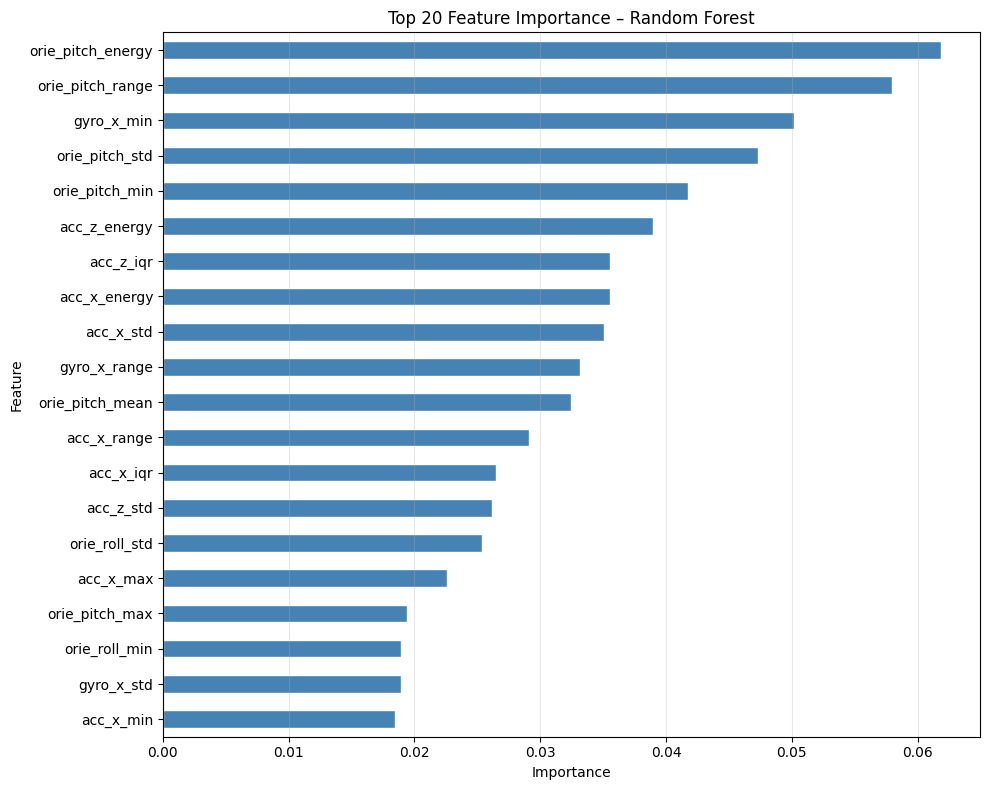

In [126]:
# Feature Importance (nur fuer baumbasierte Modelle)
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        "Feature":    feature_cols,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("Top 20 Features:")
    print(fi_df.head(20).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    fi_df.head(20).sort_values("Importance").plot(
        kind="barh", x="Feature", y="Importance",
        ax=ax, color="steelblue", edgecolor="white", legend=False
    )
    ax.set_title(f"Top 20 Feature Importance – {best_name}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PROCESSED_PATH}/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Feature Importance nicht verfuegbar fuer {best_name}. Weiter mit SHAP.")


## 8. Modell exportieren


In [127]:
# Modell speichern
model_path = f"{PROCESSED_PATH}/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# Modell-Metadaten speichern
import json
metadata = {
    "model_name":    best_name,
    "classes":       list(best_model.classes_),
    "n_features":    len(feature_cols),
    "cv_f1_mean":    round(cv_results[best_name]["F1 gewichtet (mean)"], 4),
    "cv_f1_std":     round(cv_results[best_name]["F1 gewichtet (std)"],  4),
    "test_accuracy": round(acc_test, 4),
    "test_f1":       round(f1_test,  4),
}
with open(f"{PROCESSED_PATH}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Modell gespeichert: {model_path}")
print(f"Metadaten: model_metadata.json")
print()
print("Gespeicherte Dateien in data/processed/:")
for fname in sorted(os.listdir(PROCESSED_PATH)):
    size = os.path.getsize(f"{PROCESSED_PATH}/{fname}")
    print(f"  {fname:45s} {size:>10,} bytes")


Modell gespeichert: ../data/processed/model.pkl
Metadaten: model_metadata.json

Gespeicherte Dateien in data/processed/:
  X_test.csv                                       400,848 bytes
  X_train.csv                                    1,863,176 bytes
  X_val.csv                                        399,727 bytes
  class_distribution.png                            58,920 bytes
  confusion_matrix_best.png                        100,402 bytes
  feature_distribution.png                          54,054 bytes
  feature_importance.png                            71,625 bytes
  feature_names.txt                                    964 bytes
  features_all.csv                               2,527,152 bytes
  mixed_confusion_matrix.png                        76,879 bytes
  mixed_evaluation.png                             145,570 bytes
  model.pkl                                      1,021,834 bytes
  model_comparison_cv.png                           47,351 bytes
  model_metadata.json             

## 9. Mixed-Evaluation

Anwendung des Modells auf zusammengesetzte Aktivitaetsaufnahmen aus `data/mixed/`.
Jede Session enthaelt eine `Annotation.csv` mit `start_s, end_s, label` als Ground Truth.
Konfusionsmatrix: Vorhersage vs. annotierte Ground Truth.


Mixed-Sessions geladen:  4
Fenster gesamt:          672
  davon annotiert:       608


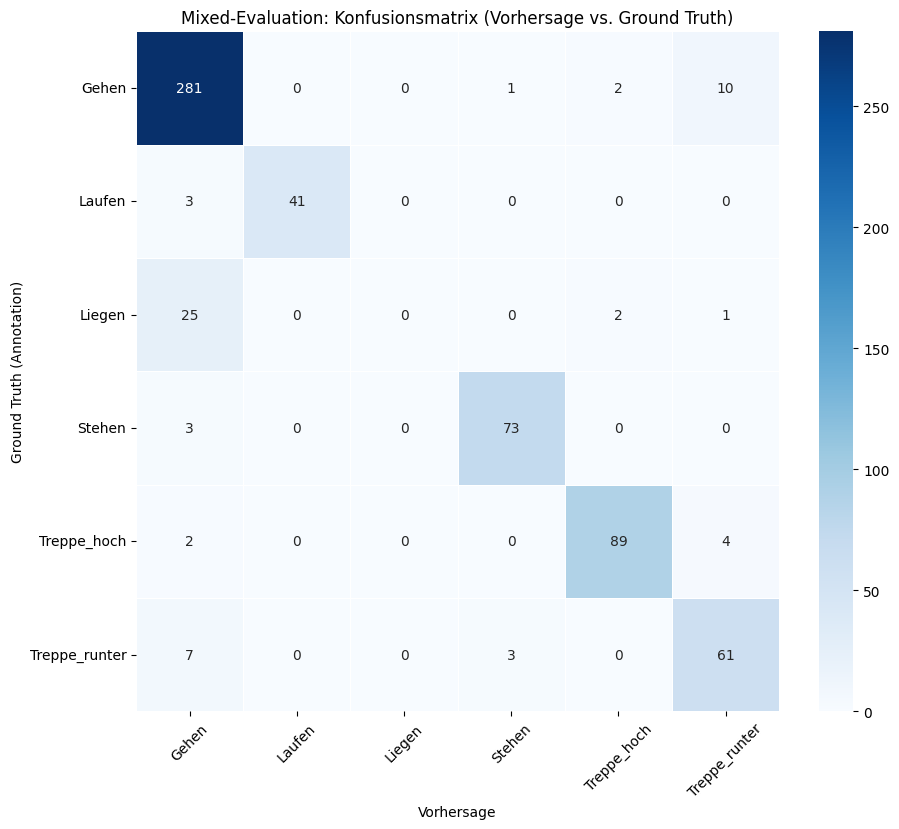


Klassifikationsreport (Mixed-Evaluation):
               precision    recall  f1-score   support

        Gehen       0.88      0.96      0.91       294
       Laufen       1.00      0.93      0.96        44
       Liegen       0.00      0.00      0.00        28
       Stehen       0.95      0.96      0.95        76
  Treppe_hoch       0.96      0.94      0.95        95
Treppe_runter       0.80      0.86      0.83        71

     accuracy                           0.90       608
    macro avg       0.76      0.77      0.77       608
 weighted avg       0.86      0.90      0.88       608



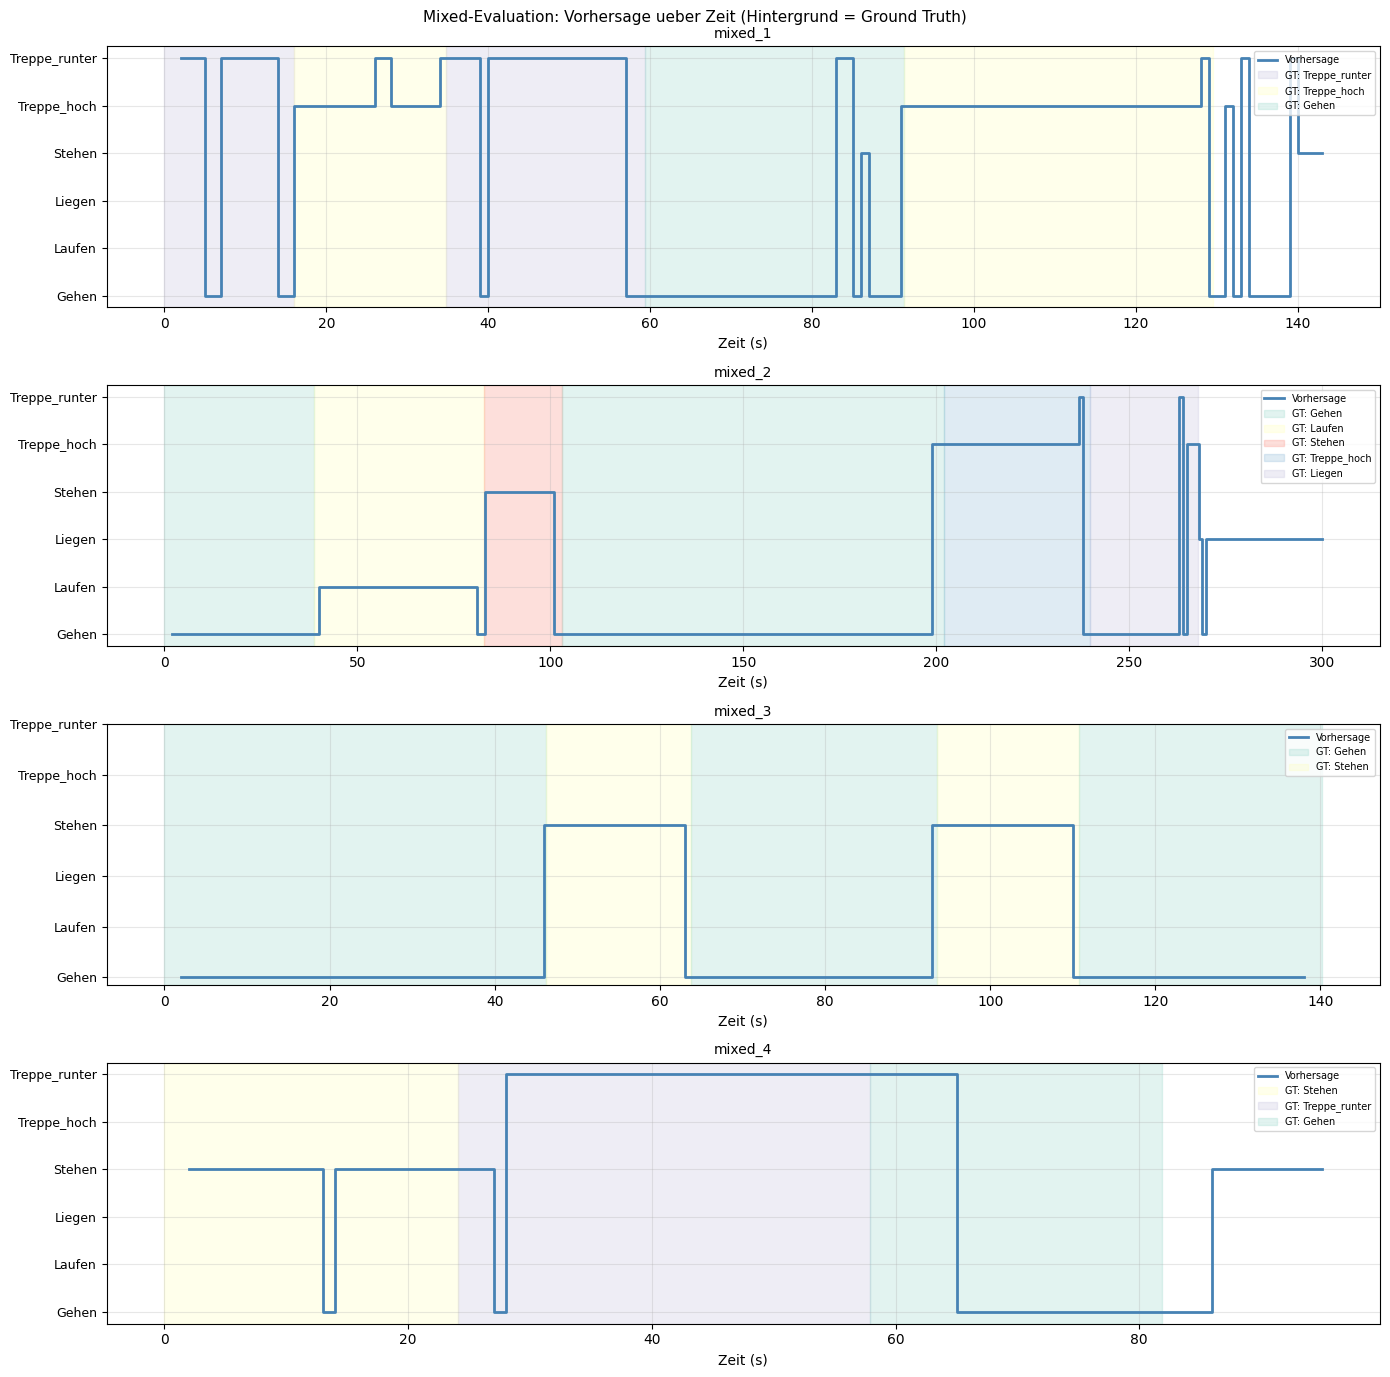

In [128]:
TRIM_SECONDS  = 2.0
WINDOW_SIZE_S = 2.0
STEP_SIZE_S   = 1.0
MAX_GAP_S     = 5.0

FEATURE_COLS_RAW = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "orie_roll", "orie_pitch", "orie_yaw"
]

def compute_features_mixed(window):
    features = {}
    for col in FEATURE_COLS_RAW:
        if col not in window.columns:
            continue
        s = window[col].dropna()
        if len(s) < 5:
            continue
        features[f"{col}_mean"]   = s.mean()
        features[f"{col}_std"]    = s.std()
        features[f"{col}_min"]    = s.min()
        features[f"{col}_max"]    = s.max()
        features[f"{col}_range"]  = s.max() - s.min()
        features[f"{col}_energy"] = (s**2).mean()
        features[f"{col}_iqr"]    = s.quantile(0.75) - s.quantile(0.25)
        features[f"{col}_zcr"]    = ((s.iloc[:-1].values * s.iloc[1:].values) < 0).sum() / len(s)
    return features


def get_ground_truth(window_center, annotations):
    for _, row in annotations.iterrows():
        if row["start_s"] <= window_center < row["end_s"]:
            return row["label"]
    return None


if not os.path.exists(MIXED_PATH):
    print(f"Mixed-Ordner nicht gefunden: {MIXED_PATH}")
else:
    mixed_windows  = []
    skipped_broken = []

    for session in sorted(os.listdir(MIXED_PATH)):
        session_path = os.path.join(MIXED_PATH, session)
        if not os.path.isdir(session_path):
            continue

        # Annotation laden
        ann_path = os.path.join(session_path, "Annotation.csv")
        if not os.path.exists(ann_path):
            print(f"  {session}: Annotation.csv fehlt – uebersprungen")
            continue
        annotations = pd.read_csv(ann_path)

        # Sensordaten laden (Orientation optional)
        dfs = {}
        for sensor_file in ["Accelerometer.csv", "Gyroscope.csv", "Orientation.csv"]:
            fp = os.path.join(session_path, sensor_file)
            if not os.path.exists(fp):
                continue
            df = pd.read_csv(fp)
            df["time_s"] = (df["time"] - df["time"].iloc[0]) / 1e9
            df = df.drop(columns=["time", "seconds_elapsed"], errors="ignore")
            sname  = sensor_file.replace(".csv", "")
            prefix = SENSOR_PREFIX.get(sname, sname[:4].lower())
            cols   = SENSOR_COLUMNS.get(sname, [])
            df = df.rename(columns={c: f"{prefix}_{c}" for c in cols if c in df.columns})
            keep = ["time_s"] + [f"{prefix}_{c}" for c in cols]
            df = df[[c for c in keep if c in df.columns]]
            dfs[sname] = df

        if "Accelerometer" not in dfs:
            skipped_broken.append(f"{session} (kein Accelerometer)")
            continue

        # Sensoren zusammenfuehren
        df_m = dfs["Accelerometer"].sort_values("time_s")
        for sname in ["Gyroscope", "Orientation"]:
            if sname in dfs:
                df_m = pd.merge_asof(df_m, dfs[sname].sort_values("time_s"),
                                     on="time_s", direction="nearest", tolerance=0.05)

        # Gap-Check
        max_gap = df_m["time_s"].diff().max()
        if max_gap > MAX_GAP_S:
            skipped_broken.append(f"{session} (Luecke {max_gap:.1f}s)")
            continue

        # Trim
        t_min = df_m["time_s"].min() + TRIM_SECONDS
        t_max = df_m["time_s"].max() - TRIM_SECONDS
        df_m  = df_m[(df_m["time_s"] >= t_min) & (df_m["time_s"] <= t_max)].copy()
        if len(df_m) < 10:
            skipped_broken.append(f"{session} (zu kurz nach Trim)")
            continue

        # Sliding Window
        t     = df_m["time_s"].min()
        t_end = df_m["time_s"].max()
        while t + WINDOW_SIZE_S <= t_end:
            window = df_m[(df_m["time_s"] >= t) & (df_m["time_s"] < t + WINDOW_SIZE_S)]
            if len(window) >= 10:
                feats = compute_features_mixed(window)
                center = t + WINDOW_SIZE_S / 2.0
                feats["session"]         = session
                feats["window_start_s"]  = round(t, 2)
                feats["window_center_s"] = round(center, 2)
                feats["true_label"]      = get_ground_truth(center, annotations)
                mixed_windows.append(feats)
            t += STEP_SIZE_S

    if skipped_broken:
        print("Uebersprungene Mixed-Sessions:")
        for s in skipped_broken:
            print(f"  ! {s}")

    if not mixed_windows:
        print("\nKeine gueltigen Mixed-Sessions verfuegbar.")
    else:
        df_mixed = pd.DataFrame(mixed_windows)

        # Vorhersage
        X_mixed_raw    = df_mixed.reindex(columns=feature_cols, fill_value=0).fillna(0)
        X_mixed_scaled = pd.DataFrame(scaler.transform(X_mixed_raw), columns=feature_cols)
        df_mixed["predicted"] = best_model.predict(X_mixed_scaled)

        print(f"Mixed-Sessions geladen:  {df_mixed['session'].nunique()}")
        print(f"Fenster gesamt:          {len(df_mixed)}")

        # Nur annotierte Fenster fuer Konfusionsmatrix
        df_eval = df_mixed[df_mixed["true_label"].notna()].copy()
        print(f"  davon annotiert:       {len(df_eval)}")

        if len(df_eval) > 0:
            true_labels = sorted(df_eval["true_label"].unique())
            pred_labels = sorted(df_eval["predicted"].unique())
            all_labels  = sorted(set(true_labels) | set(pred_labels))

            cm_mixed = confusion_matrix(df_eval["true_label"], df_eval["predicted"], labels=all_labels)

            fig, ax = plt.subplots(figsize=(max(8, len(all_labels) * 1.6), max(6, len(all_labels) * 1.4)))
            sns.heatmap(
                cm_mixed, annot=True, fmt="d", cmap="Blues",
                xticklabels=all_labels, yticklabels=all_labels,
                ax=ax, linewidths=0.5
            )
            ax.set_title("Mixed-Evaluation: Konfusionsmatrix (Vorhersage vs. Ground Truth)")
            ax.set_ylabel("Ground Truth (Annotation)")
            ax.set_xlabel("Vorhersage")
            ax.tick_params(axis="x", rotation=45)
            ax.tick_params(axis="y", rotation=0)
            plt.tight_layout()
            plt.savefig(f"{PROCESSED_PATH}/mixed_confusion_matrix.png", dpi=150, bbox_inches="tight")
            plt.show()

            print("\nKlassifikationsreport (Mixed-Evaluation):")
            print(classification_report(df_eval["true_label"], df_eval["predicted"],
                                        labels=all_labels, zero_division=0))

        # Zeitlicher Verlauf je Session
        session_names    = sorted(df_mixed["session"].unique())
        all_plot_classes = sorted(df_mixed["predicted"].unique())
        class_to_int     = {c: i for i, c in enumerate(all_plot_classes)}

        fig, axes = plt.subplots(len(session_names), 1,
                                 figsize=(14, 3.5 * len(session_names)), sharex=False)
        if len(session_names) == 1:
            axes = [axes]

        cmap_colors = plt.cm.Set3.colors
        for ax, sname in zip(axes, session_names):
            df_s       = df_mixed[df_mixed["session"] == sname].sort_values("window_start_s")
            y_pred_int = df_s["predicted"].map(class_to_int).fillna(-1)
            ax.step(df_s["window_start_s"], y_pred_int, where="post",
                    linewidth=2.0, label="Vorhersage", color="steelblue", zorder=3)

            # Ground-Truth Segmente als Hintergrund
            ann_path = os.path.join(MIXED_PATH, sname, "Annotation.csv")
            if os.path.exists(ann_path):
                ann = pd.read_csv(ann_path)
                unique_ann_labels = sorted(ann["label"].unique())
                label_colors = {lbl: cmap_colors[i % len(cmap_colors)]
                                for i, lbl in enumerate(unique_ann_labels)}
                plotted_labels = set()
                for _, row in ann.iterrows():
                    lbl = row["label"]
                    ax.axvspan(row["start_s"], row["end_s"],
                               alpha=0.25, color=label_colors[lbl],
                               label=f"GT: {lbl}" if lbl not in plotted_labels else "")
                    plotted_labels.add(lbl)

            ax.set_yticks(list(class_to_int.values()))
            ax.set_yticklabels(list(class_to_int.keys()), fontsize=9)
            ax.set_title(sname, fontsize=10)
            ax.set_xlabel("Zeit (s)")
            ax.grid(True, alpha=0.3)
            handles, labels = ax.get_legend_handles_labels()
            by_label = dict(zip(labels, handles))
            ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=7)

        plt.suptitle("Mixed-Evaluation: Vorhersage ueber Zeit (Hintergrund = Ground Truth)", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{PROCESSED_PATH}/mixed_evaluation.png", dpi=150, bbox_inches="tight")
        plt.show()


In [129]:
print("=== Modellvergleich (5-fold Cross-Validation) ===")
df_cv_print = pd.DataFrame({
    n: {
        "CV F1 (mean)": f"{v['F1 gewichtet (mean)']:.4f}",
        "CV F1 (+/-)":  f"{v['F1 gewichtet (std)']:.4f}",
        "CV Acc":       f"{v['Accuracy (mean)']:.4f}",
    }
    for n, v in cv_results.items()
}).T
print(df_cv_print.to_string())
print(f"\n=== Bestes Modell auf Test-Set: {best_name} ===")
print(f"  Accuracy:     {acc_test:.4f}")
print(f"  F1 gewichtet: {f1_test:.4f}")


=== Modellvergleich (5-fold Cross-Validation) ===
                  CV F1 (mean) CV F1 (+/-)  CV Acc
Decision Tree           0.9671      0.0113  0.9674
Random Forest           0.9855      0.0052  0.9856
Gradient Boosting       0.9823      0.0066  0.9824
KNN                     0.9799      0.0055  0.9799
SVM                     0.9818      0.0072  0.9818

=== Bestes Modell auf Test-Set: Random Forest ===
  Accuracy:     0.9929
  F1 gewichtet: 0.9929


## 10. Zusammenfassung & Bias-Diskussion

### Ergebnisse

| Modell            | CV F1 (mean ± std)  | Test Accuracy | Test F1 |
|-------------------|---------------------|---------------|---------|
| Decision Tree     | 0.9671 ± 0.0113     | –             | –       |
| **Random Forest** | **0.9855 ± 0.0052** | **0.9929**    | **0.9929** |
| Gradient Boosting | 0.9823 ± 0.0066     | –             | –       |
| KNN               | 0.9799 ± 0.0055     | –             | –       |
| SVM               | 0.9818 ± 0.0072     | –             | –       |

**Bestes Modell:** Random Forest – hoechster CV F1 (0.9855) mit geringstem Varianz (±0.0052).
Test-Set: Accuracy = 0.9929, F1 = 0.9929.
Treppe_hoch (n=12 im Test): Precision=1.00, Recall=1.00, F1=1.00.
Treppe_runter (n=15): Precision=1.00, Recall=1.00, F1=1.00.

### Bias-Diskussion

| Bias-Quelle | Beobachtete Auswirkung |
|-------------|----------------------|
| Wenige Personen (~2–3) | Modell koennte individuelle Gangmuster ueberfitten |
| Handy immer Hosentasche | Andere Trageweisen (Hand, Rucksack) wuerden abweichen |
| Klassenungleichgewicht | Treppe_hoch/runter mit weniger Daten → class_weight='balanced' gesetzt |
| 61 Hz vs. 100 Hz Geraete | Unterschiedliche Sampling-Raten erzeugen leicht verschiedene Feature-Verteilungen |

### Naechste Schritte

- App-Integration: Modell aus `data/processed/model.pkl` laden, Mehrheitsvoting (N=3 Fenster) an Uebergaengen
- Mehr Trainingsdaten sammeln, insbesondere fuer Treppe_hoch/runter
- Weitere Personen aufnehmen zur Generalisierung
